In [32]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable

In [33]:
import pandas as pd

# Leggi tutto come stringa (per ora)
with open("risultati_synchro_queue_cluster_runs30_nel32000_thread12345678.txt", "r") as f:
    lines = f.readlines()

# Processa ogni riga
data = []
for line in lines:
    parts = line.split()            # dividi per spazi
    tipo_coda, metodo, thread = parts[:3]   # prime 3 colonne
    valori = list(map(int, parts[3:]))      # tutti i restanti valori in lista
    data.append([tipo_coda, metodo, thread, valori])

# Crea DataFrame
df = pd.DataFrame(data, columns=["tipo_coda", "metodo", "thread", "valori"])

# Visualizza
print(df.head())

  tipo_coda      metodo   thread  \
0     deque  Push_Front  multi_1   
1     deque   Push_Back  multi_1   
2     deque   Pop_Front  multi_1   
3     deque    Pop_Back  multi_1   
4   relaxed  Push_Front  multi_1   

                                              valori  
0  [44984, 36591, 34801, 33041, 41078, 40433, 441...  
1  [41319, 36800, 35913, 32935, 40601, 35406, 433...  
2  [37409, 36798, 38600, 38464, 38250, 37161, 369...  
3  [36339, 33184, 36202, 39239, 36678, 33093, 313...  
4  [21989, 28329, 31297, 22120, 21330, 29213, 222...  


## sigle thread

In [34]:
def plot(data_list, title, labels):

    fig, ax = plt.subplots(figsize=[8, 8])

    boxes = []
    ticks = []

    for i in range(0,len(data_list)):
        boxes.append(data_list[i])
        ticks.append(labels[i])

    bplot = ax.boxplot(boxes, showfliers=False)
    # Etichette per gli assi
    ax.set_xticks(range(1,len(labels)+1),ticks)
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)
    ax.set_yscale('log')

    for median in bplot['medians']:
        median.set_color('red')
    plt.figtext(0.78, 0.9, f"runs: {len(data_list[0])}\nn_elem: {n_elem}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))
    plt.show()

In [40]:
code = ["deque","relaxed","deferred","blocking"]
metodi = ["Push_Front","Push_Back","Pop_Front","Pop_Back","random"]
thread = ["single", "multi_1", "multi_2","multi_3", "multi_4","multi_5", "multi_6","multi_7","multi_8"]

for c in code:
    for m in metodi:
        for t in thread:
            subset = df[(df["tipo_coda"]==c) & (df["metodo"]==m) & (df["thread"]==t)]
            if not subset.empty:
                valori = subset.iloc[0]["valori"]
                # Crea variabile dinamica
                nome_var = f"{c}_{m}_{t}"
                globals()[nome_var] = valori


pop back

=== Pop_Back Single Thread ===
deque: 24009.0
blocking: 26334.5
deferred: 26342.0
relaxed: 23486.5


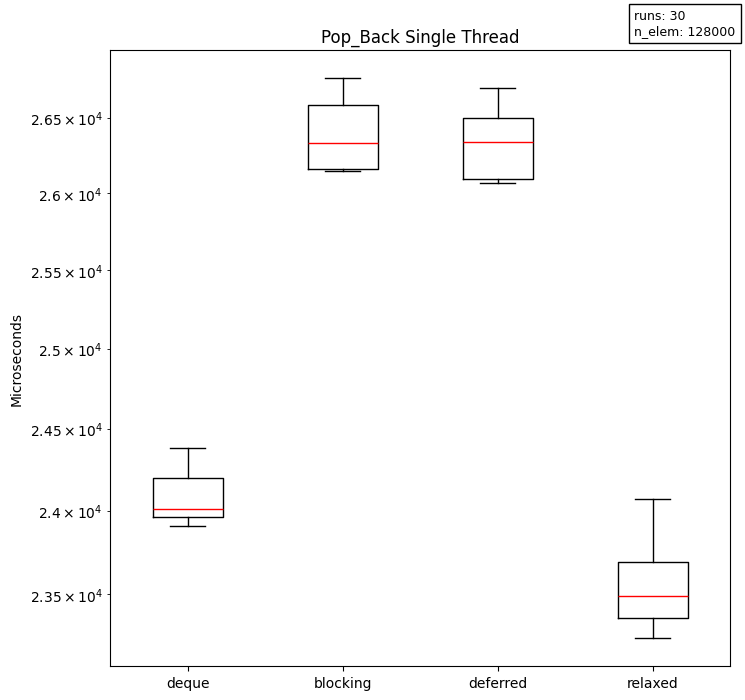


=== Pop_Front Single Thread ===
deque: 24585.5
blocking: 26038.0
deferred: 25982.5
relaxed: 23301.0


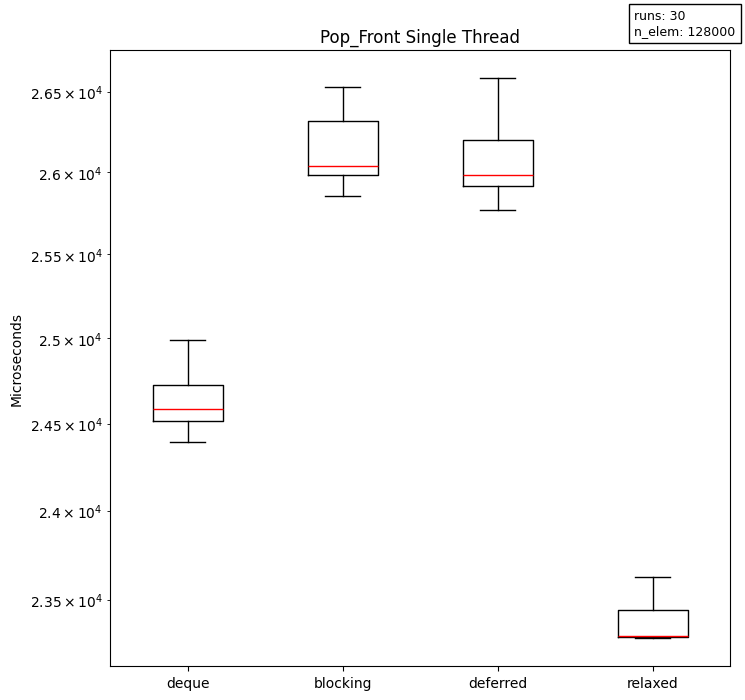


=== Push_Back Single Thread ===
deque: 28363.5
blocking: 19281.5
deferred: 19312.0
relaxed: 16640.5


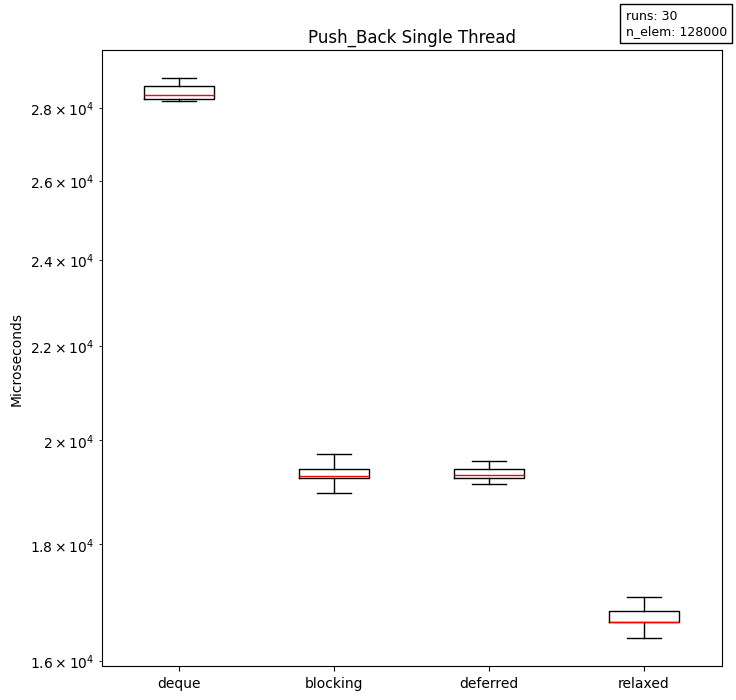


=== Push_Front Single Thread ===
deque: 28623.5
blocking: 19535.5
deferred: 19310.0
relaxed: 16616.0


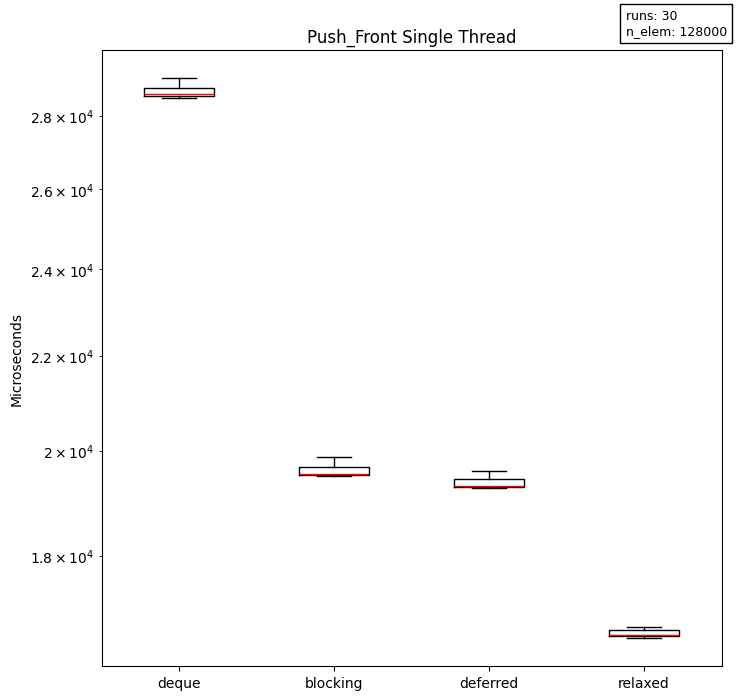

In [41]:
# dati test
nomi = ["deque", "blocking", "deferred", "relaxed"]

# ===================== DATI SINGLE THREAD =====================
# POP_BACK per thread single
dati_pop_back_single = [
    deque_Pop_Back_single,
    blocking_Pop_Back_single,
    deferred_Pop_Back_single,
    relaxed_Pop_Back_single
]

# POP_FRONT per thread single
dati_pop_front_single = [
    deque_Pop_Front_single,
    blocking_Pop_Front_single,
    deferred_Pop_Front_single,
    relaxed_Pop_Front_single
]

# PUSH_BACK per thread single
dati_push_back_single = [
    deque_Push_Back_single,
    blocking_Push_Back_single,
    deferred_Push_Back_single,
    relaxed_Push_Back_single
]

# PUSH_FRONT per thread single
dati_push_front_single = [
    deque_Push_Front_single,
    blocking_Push_Front_single,
    deferred_Push_Front_single,
    relaxed_Push_Front_single
]

n_elem = 128000

# ===================== Calcola e stampa le mediane =====================
print("=== Pop_Back Single Thread ===")
for nome, dati in zip(nomi, dati_pop_back_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_pop_back_single, "Pop_Back Single Thread", nomi)

print("\n=== Pop_Front Single Thread ===")
for nome, dati in zip(nomi, dati_pop_front_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_pop_front_single, "Pop_Front Single Thread", nomi)

print("\n=== Push_Back Single Thread ===")
for nome, dati in zip(nomi, dati_push_back_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_push_back_single, "Push_Back Single Thread", nomi)

print("\n=== Push_Front Single Thread ===")
for nome, dati in zip(nomi, dati_push_front_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_push_front_single, "Push_Front Single Thread", nomi)


## multithread

In [44]:
n_thread = [1,2,3,4,5,6,7,8] #,4,8,12,16] #,12,16] #hard code in .sh copialo da li
n_elem = 32000 ##hard code quando fai run di fie.sh

In [45]:
def multi_plot(data1, data2, data3, data4, title, labels, n_threads):
    fig, ax = plt.subplots(figsize=[10, 10])

    boxes = []
    colors = []
    group_positions = []  # Per le etichette centrate

    color_map = ["peachpuff", "orange", "yellow", "blue"]

    for i in range(len(n_threads)):
        boxes.extend([data1[i], data2[i], data3[i], data4[i]])
        colors.extend(color_map)
        # Ogni gruppo di 4 box parte alla posizione 4*i+1 → il centro è +1.5
        group_center = 4 * i + 2.5
        group_positions.append(group_center)

    # Crea boxplot
    bplot = ax.boxplot(boxes, showfliers=False, patch_artist=True)

    # Colori per ogni box
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    # Etichette centrate per ogni gruppo
    ax.set_xticks(group_positions)
    ax.set_xticklabels([str(n) for n in n_threads])

    # Etichette e titolo
    ax.set_ylabel('Microseconds')
    ax.set_xlabel('n_threads')
    ax.set_title(title, loc='left')
    ax.set_yscale('log')
    
    # Legenda (usiamo solo il primo gruppo per i colori)
    legend_handles = [bplot["boxes"][i] for i in range(4)]
    ax.legend(legend_handles, labels, loc='upper right')

    # Mediane in rosso
    for median in bplot['medians']:
        median.set_color('red')

    plt.figtext(0.78, 0.98, f"runs: {len(data1[0])}\nn_elem: {n_elem}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

    plt.tight_layout()
    plt.show()

    # ======= Calcolo e stampa delle mediane numeriche =======
    print(f"\n=== Median values for {title} ===")
    medians = [np.median(b) for b in boxes]
    
    for i, n in enumerate(n_threads):
        print(f"\nThreads = {n}")
        for j, label in enumerate(labels):
            idx = i * 4 + j
            print(f"  {label:>12}: {medians[idx]:.2f}")


In [46]:
# ===================== DEQUE =====================
dati_deque_Push_Front_multi = [
    deque_Push_Front_multi_1,
    deque_Push_Front_multi_2,
    deque_Push_Front_multi_3,
    deque_Push_Front_multi_4,
    deque_Push_Front_multi_5,
    deque_Push_Front_multi_6,
    deque_Push_Front_multi_7,
    deque_Push_Front_multi_8
]

dati_deque_Push_Back_multi = [
    deque_Push_Back_multi_1,
    deque_Push_Back_multi_2,
    deque_Push_Back_multi_3,
    deque_Push_Back_multi_4,
    deque_Push_Back_multi_5,
    deque_Push_Back_multi_6,
    deque_Push_Back_multi_7,
    deque_Push_Back_multi_8
]

dati_deque_Pop_Front_multi = [
    deque_Pop_Front_multi_1,
    deque_Pop_Front_multi_2,
    deque_Pop_Front_multi_3,
    deque_Pop_Front_multi_4,
    deque_Pop_Front_multi_5,
    deque_Pop_Front_multi_6,
    deque_Pop_Front_multi_7,
    deque_Pop_Front_multi_8
]

dati_deque_Pop_Back_multi = [
    deque_Pop_Back_multi_1,
    deque_Pop_Back_multi_2,
    deque_Pop_Back_multi_3,
    deque_Pop_Back_multi_4,
    deque_Pop_Back_multi_5,
    deque_Pop_Back_multi_6,
    deque_Pop_Back_multi_7,
    deque_Pop_Back_multi_8
]

# ===================== RELAXED =====================
dati_relaxed_Push_Front_multi = [
    relaxed_Push_Front_multi_1,
    relaxed_Push_Front_multi_2,
    relaxed_Push_Front_multi_3,
    relaxed_Push_Front_multi_4,
    relaxed_Push_Front_multi_5,
    relaxed_Push_Front_multi_6,
    relaxed_Push_Front_multi_7,
    relaxed_Push_Front_multi_8
]

dati_relaxed_Push_Back_multi = [
    relaxed_Push_Back_multi_1,
    relaxed_Push_Back_multi_2,
    relaxed_Push_Back_multi_3,
    relaxed_Push_Back_multi_4,
    relaxed_Push_Back_multi_5,
    relaxed_Push_Back_multi_6,
    relaxed_Push_Back_multi_7,
    relaxed_Push_Back_multi_8
]

dati_relaxed_Pop_Front_multi = [
    relaxed_Pop_Front_multi_1,
    relaxed_Pop_Front_multi_2,
    relaxed_Pop_Front_multi_3,
    relaxed_Pop_Front_multi_4,
    relaxed_Pop_Front_multi_5,
    relaxed_Pop_Front_multi_6,
    relaxed_Pop_Front_multi_7,
    relaxed_Pop_Front_multi_8
]

dati_relaxed_Pop_Back_multi = [
    relaxed_Pop_Back_multi_1,
    relaxed_Pop_Back_multi_2,
    relaxed_Pop_Back_multi_3,
    relaxed_Pop_Back_multi_4,
    relaxed_Pop_Back_multi_5,
    relaxed_Pop_Back_multi_6,
    relaxed_Pop_Back_multi_7,
    relaxed_Pop_Back_multi_8
]

# ===================== DEFERRED =====================
dati_deferred_Push_Front_multi = [
    deferred_Push_Front_multi_1,
    deferred_Push_Front_multi_2,
    deferred_Push_Front_multi_3,
    deferred_Push_Front_multi_4,
    deferred_Push_Front_multi_5,
    deferred_Push_Front_multi_6,
    deferred_Push_Front_multi_7,
    deferred_Push_Front_multi_8
]

dati_deferred_Push_Back_multi = [
    deferred_Push_Back_multi_1,
    deferred_Push_Back_multi_2,
    deferred_Push_Back_multi_3,
    deferred_Push_Back_multi_4,
    deferred_Push_Back_multi_5,
    deferred_Push_Back_multi_6,
    deferred_Push_Back_multi_7,
    deferred_Push_Back_multi_8
]

dati_deferred_Pop_Front_multi = [
    deferred_Pop_Front_multi_1,
    deferred_Pop_Front_multi_2,
    deferred_Pop_Front_multi_3,
    deferred_Pop_Front_multi_4,
    deferred_Pop_Front_multi_5,
    deferred_Pop_Front_multi_6,
    deferred_Pop_Front_multi_7,
    deferred_Pop_Front_multi_8
]

dati_deferred_Pop_Back_multi = [
    deferred_Pop_Back_multi_1,
    deferred_Pop_Back_multi_2,
    deferred_Pop_Back_multi_3,
    deferred_Pop_Back_multi_4,
    deferred_Pop_Back_multi_5,
    deferred_Pop_Back_multi_6,
    deferred_Pop_Back_multi_7,
    deferred_Pop_Back_multi_8
]

# ===================== BLOCKING =====================
dati_blocking_Push_Front_multi = [
    blocking_Push_Front_multi_1,
    blocking_Push_Front_multi_2,
    blocking_Push_Front_multi_3,
    blocking_Push_Front_multi_4,
    blocking_Push_Front_multi_5,
    blocking_Push_Front_multi_6,
    blocking_Push_Front_multi_7,
    blocking_Push_Front_multi_8
]

dati_blocking_Push_Back_multi = [
    blocking_Push_Back_multi_1,
    blocking_Push_Back_multi_2,
    blocking_Push_Back_multi_3,
    blocking_Push_Back_multi_4,
    blocking_Push_Back_multi_5,
    blocking_Push_Back_multi_6,
    blocking_Push_Back_multi_7,
    blocking_Push_Back_multi_8
]

dati_blocking_Pop_Front_multi = [
    blocking_Pop_Front_multi_1,
    blocking_Pop_Front_multi_2,
    blocking_Pop_Front_multi_3,
    blocking_Pop_Front_multi_4,
    blocking_Pop_Front_multi_5,
    blocking_Pop_Front_multi_6,
    blocking_Pop_Front_multi_7,
    blocking_Pop_Front_multi_8
]

dati_blocking_Pop_Back_multi = [
    blocking_Pop_Back_multi_1,
    blocking_Pop_Back_multi_2,
    blocking_Pop_Back_multi_3,
    blocking_Pop_Back_multi_4,
    blocking_Pop_Back_multi_5,
    blocking_Pop_Back_multi_6,
    blocking_Pop_Back_multi_7,
    blocking_Pop_Back_multi_8
]


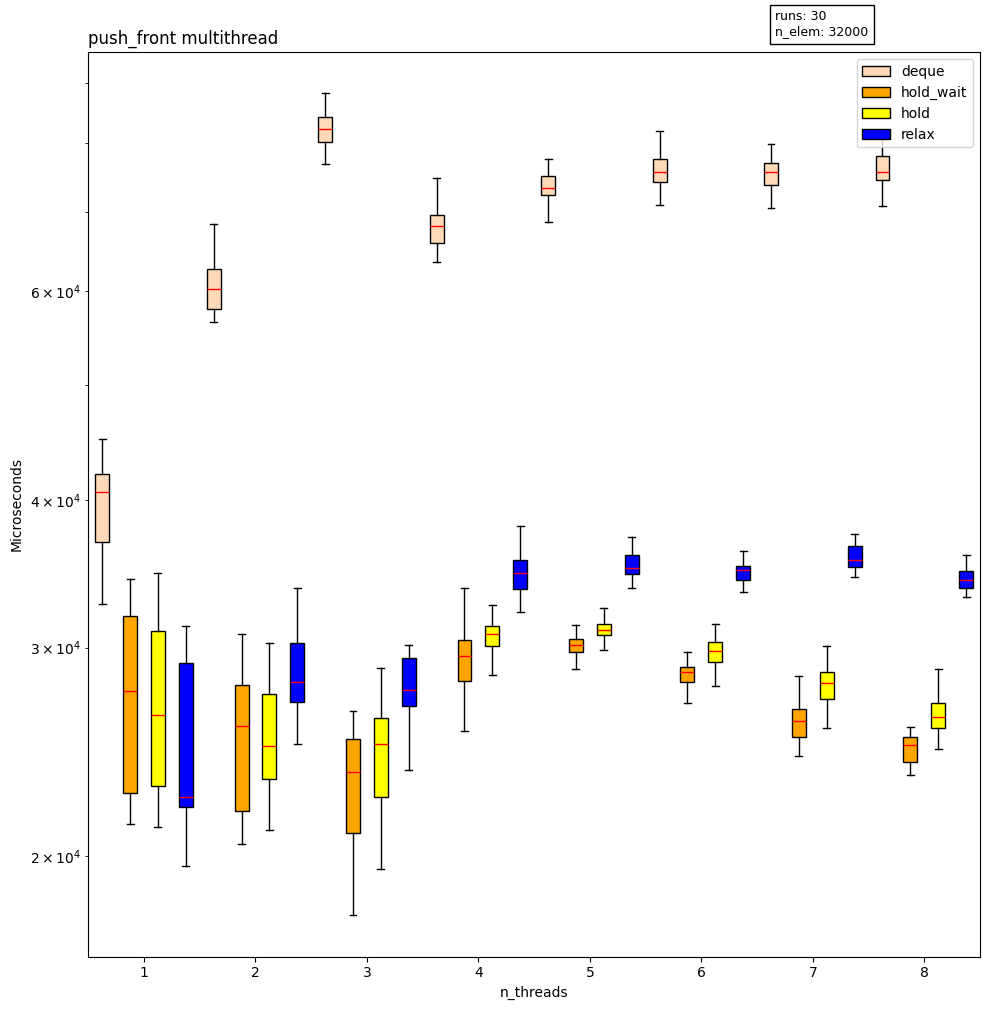


=== Median values for push_front multithread ===

Threads = 1
         deque: 40589.50
     hold_wait: 27572.00
          hold: 26334.50
         relax: 22451.50

Threads = 2
         deque: 60218.50
     hold_wait: 25739.50
          hold: 24783.00
         relax: 28036.50

Threads = 3
         deque: 82297.00
     hold_wait: 23547.50
          hold: 24857.50
         relax: 27646.00

Threads = 4
         deque: 68101.00
     hold_wait: 29523.00
          hold: 30790.50
         relax: 34695.00

Threads = 5
         deque: 73403.00
     hold_wait: 30148.50
          hold: 31027.00
         relax: 35009.00

Threads = 6
         deque: 75741.50
     hold_wait: 28621.50
          hold: 29797.50
         relax: 34859.00

Threads = 7
         deque: 75616.00
     hold_wait: 25988.50
          hold: 27983.00
         relax: 35608.00

Threads = 8
         deque: 75691.00
     hold_wait: 24844.50
          hold: 26204.50
         relax: 34197.00


In [47]:
multi_plot(dati_deque_Push_Front_multi, dati_blocking_Push_Front_multi, dati_deferred_Push_Front_multi,dati_relaxed_Push_Front_multi , "push_front multithread", ["deque","hold_wait","hold","relax"], n_thread)

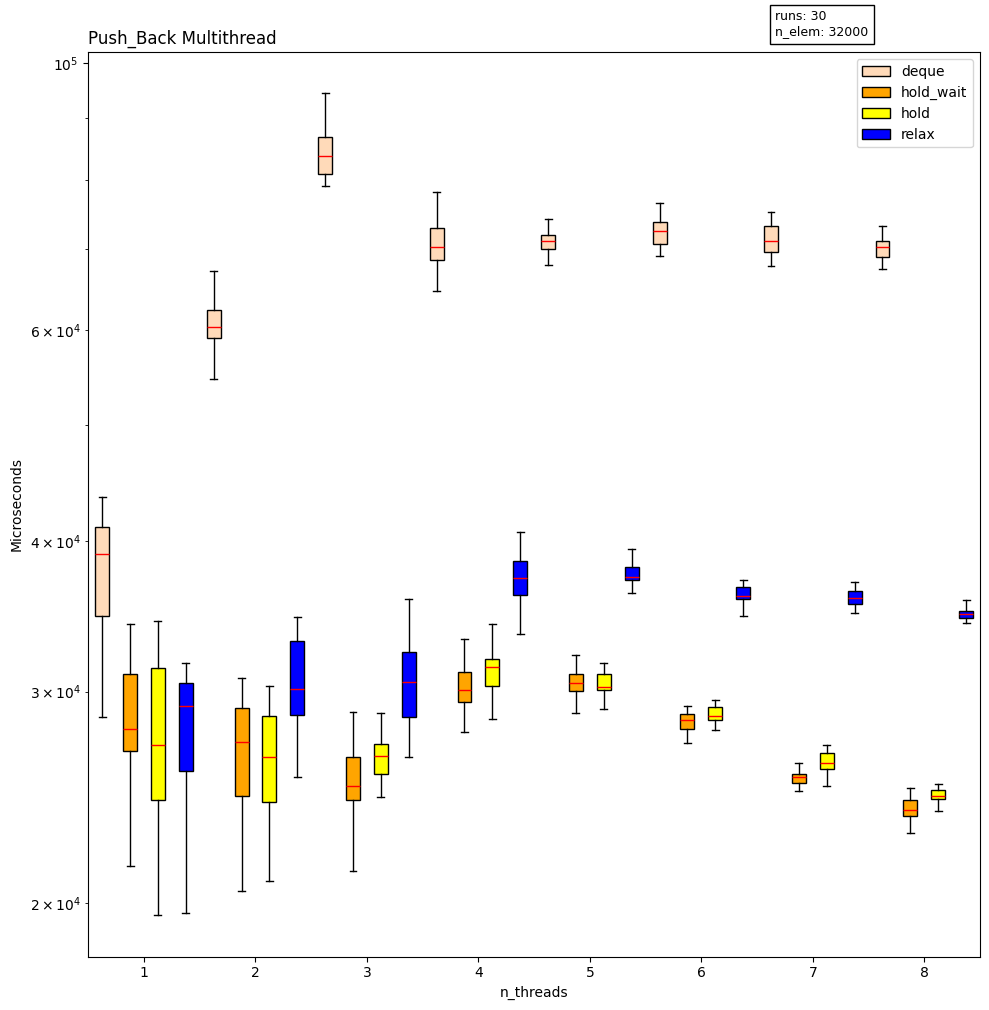


=== Median values for Push_Back Multithread ===

Threads = 1
         deque: 39050.50
     hold_wait: 27899.50
          hold: 27074.00
         relax: 29195.00

Threads = 2
         deque: 60320.50
     hold_wait: 27234.50
          hold: 26449.00
         relax: 30157.50

Threads = 3
         deque: 83658.00
     hold_wait: 25028.50
          hold: 26489.00
         relax: 30579.00

Threads = 4
         deque: 70334.00
     hold_wait: 30069.00
          hold: 31425.00
         relax: 37270.00

Threads = 5
         deque: 71099.00
     hold_wait: 30465.00
          hold: 30276.00
         relax: 37348.50

Threads = 6
         deque: 72429.00
     hold_wait: 28407.00
          hold: 28650.50
         relax: 35992.50

Threads = 7
         deque: 71180.50
     hold_wait: 25455.50
          hold: 26162.50
         relax: 35882.50

Threads = 8
         deque: 70276.50
     hold_wait: 23914.00
          hold: 24545.50
         relax: 34794.00


In [48]:
multi_plot(
    dati_deque_Push_Back_multi,
    dati_blocking_Push_Back_multi,
    dati_deferred_Push_Back_multi,
    dati_relaxed_Push_Back_multi,
    "Push_Back Multithread",
    ["deque","hold_wait","hold","relax"], n_thread
)

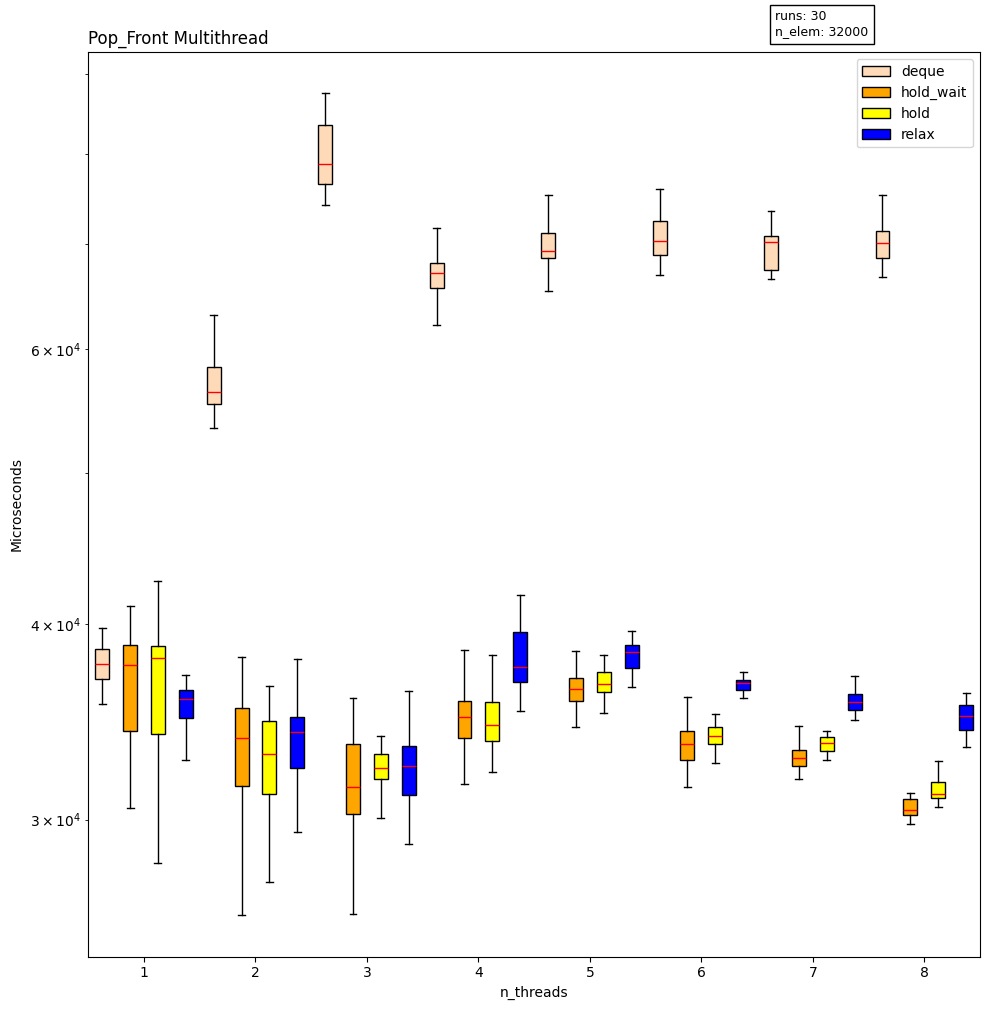


=== Median values for Pop_Front Multithread ===

Threads = 1
         deque: 37742.00
     hold_wait: 37686.00
          hold: 38070.00
         relax: 35852.50

Threads = 2
         deque: 56303.50
     hold_wait: 33845.50
          hold: 33063.50
         relax: 34109.50

Threads = 3
         deque: 78778.50
     hold_wait: 31467.00
          hold: 32386.00
         relax: 32456.00

Threads = 4
         deque: 67078.00
     hold_wait: 34878.50
          hold: 34469.00
         relax: 37571.50

Threads = 5
         deque: 69344.00
     hold_wait: 36377.00
          hold: 36613.50
         relax: 38372.50

Threads = 6
         deque: 70323.50
     hold_wait: 33525.00
          hold: 33918.00
         relax: 36673.50

Threads = 7
         deque: 70221.50
     hold_wait: 32838.50
          hold: 33569.00
         relax: 35684.00

Threads = 8
         deque: 70120.00
     hold_wait: 30437.00
          hold: 31153.50
         relax: 34948.00


In [49]:
multi_plot(
    dati_deque_Pop_Front_multi,
    dati_blocking_Pop_Front_multi,
    dati_deferred_Pop_Front_multi,
    dati_relaxed_Pop_Front_multi,
    "Pop_Front Multithread",
    ["deque","hold_wait","hold","relax"], n_thread
)

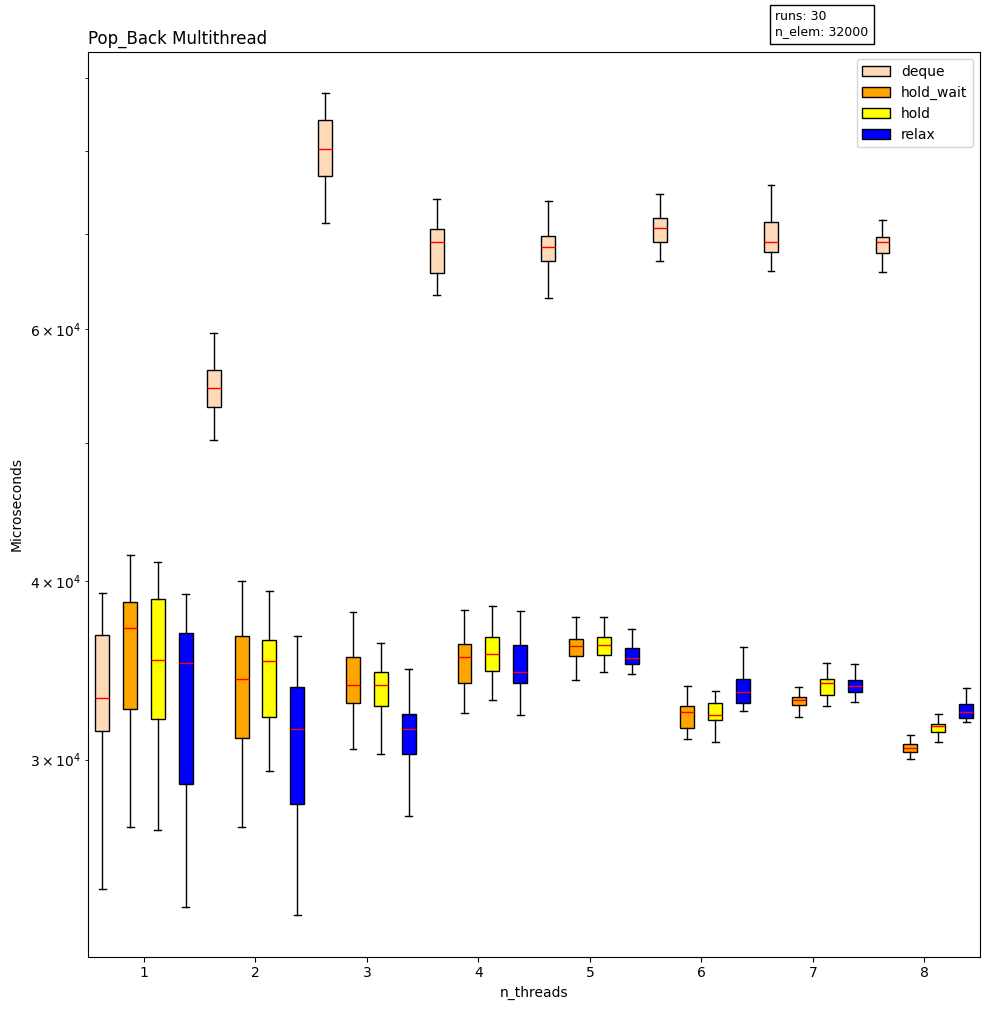


=== Median values for Pop_Back Multithread ===

Threads = 1
         deque: 33138.50
     hold_wait: 37069.50
          hold: 35212.00
         relax: 35057.50

Threads = 2
         deque: 54626.50
     hold_wait: 34174.00
          hold: 35172.50
         relax: 31536.00

Threads = 3
         deque: 80221.50
     hold_wait: 33853.50
          hold: 33847.50
         relax: 31541.50

Threads = 4
         deque: 69100.00
     hold_wait: 35419.50
          hold: 35586.00
         relax: 34530.00

Threads = 5
         deque: 68562.00
     hold_wait: 36048.50
          hold: 36056.00
         relax: 35324.50

Threads = 6
         deque: 70626.00
     hold_wait: 32385.00
          hold: 32216.50
         relax: 33455.00

Threads = 7
         deque: 69081.50
     hold_wait: 33029.00
          hold: 33922.50
         relax: 33780.00

Threads = 8
         deque: 69097.00
     hold_wait: 30549.00
          hold: 31686.00
         relax: 32403.50


In [51]:
multi_plot(
    dati_deque_Pop_Back_multi,
    dati_blocking_Pop_Back_multi,
    dati_deferred_Pop_Back_multi,
    dati_relaxed_Pop_Back_multi,
    "Pop_Back Multithread",
    ["deque","hold_wait","hold","relax"], n_thread
)

## Random

In [55]:
# ===================== DEQUE =====================
dati_deque_random_multi = [
    deque_random_multi_1,
    deque_random_multi_2,
    deque_random_multi_3,
    deque_random_multi_4,
    deque_random_multi_5,
    deque_random_multi_6,
    deque_random_multi_7,
    deque_random_multi_8
]

# ===================== RELAXED =====================
dati_relaxed_random_multi = [
    relaxed_random_multi_1,
    relaxed_random_multi_2,
    relaxed_random_multi_3,
    relaxed_random_multi_4,
    relaxed_random_multi_5,
    relaxed_random_multi_6,
    relaxed_random_multi_7,
    relaxed_random_multi_8
]

# ===================== DEFERRED =====================
dati_deferred_random_multi = [
    deferred_random_multi_1,
    deferred_random_multi_2,
    deferred_random_multi_3,
    deferred_random_multi_4,
    deferred_random_multi_5,
    deferred_random_multi_6,
    deferred_random_multi_7,
    deferred_random_multi_8
]

# ===================== BLOCKING =====================
dati_blocking_random_multi = [
    blocking_random_multi_1,
    blocking_random_multi_2,
    blocking_random_multi_3,
    blocking_random_multi_4,
    blocking_random_multi_5,
    blocking_random_multi_6,
    blocking_random_multi_7,
    blocking_random_multi_8
]


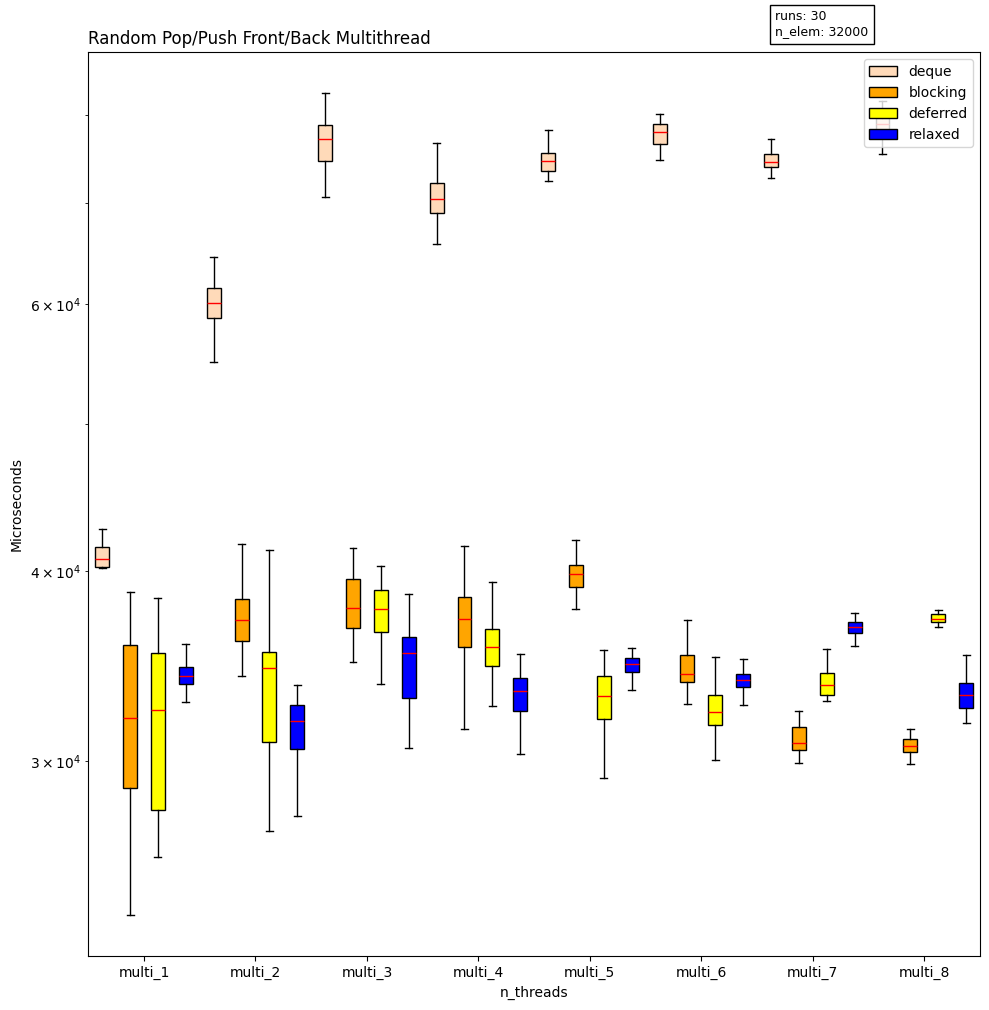


=== Median values for Random Pop/Push Front/Back Multithread ===

Threads = multi_1
         deque: 40754.50
      blocking: 31994.50
      deferred: 32383.50
       relaxed: 34102.00

Threads = multi_2
         deque: 60091.50
      blocking: 37161.50
      deferred: 34528.00
       relaxed: 31887.50

Threads = multi_3
         deque: 77136.50
      blocking: 37845.00
      deferred: 37762.00
       relaxed: 35318.50

Threads = multi_4
         deque: 70444.50
      blocking: 37198.50
      deferred: 35679.50
       relaxed: 33359.50

Threads = multi_5
         deque: 74642.00
      blocking: 39809.50
      deferred: 33082.00
       relaxed: 34722.50

Threads = multi_6
         deque: 77995.00
      blocking: 34248.50
      deferred: 32320.50
       relaxed: 33936.00

Threads = multi_7
         deque: 74545.00
      blocking: 30807.50
      deferred: 33682.50
       relaxed: 36776.50

Threads = multi_8
         deque: 78930.50
      blocking: 30699.00
      deferred: 37204.50
       

In [58]:
multi_plot(
    dati_deque_random_multi,
    dati_blocking_random_multi,
    dati_deferred_random_multi,
    dati_relaxed_random_multi,
    "Random Pop/Push Front/Back Multithread",
    ["deque","blocking","deferred","relaxed"],
    ["multi_1", "multi_2", "multi_3", "multi_4","multi_5", "multi_6", "multi_7", "multi_8"]
)
